正在保存: Comparison_BestObj_MPLStyle.pdf


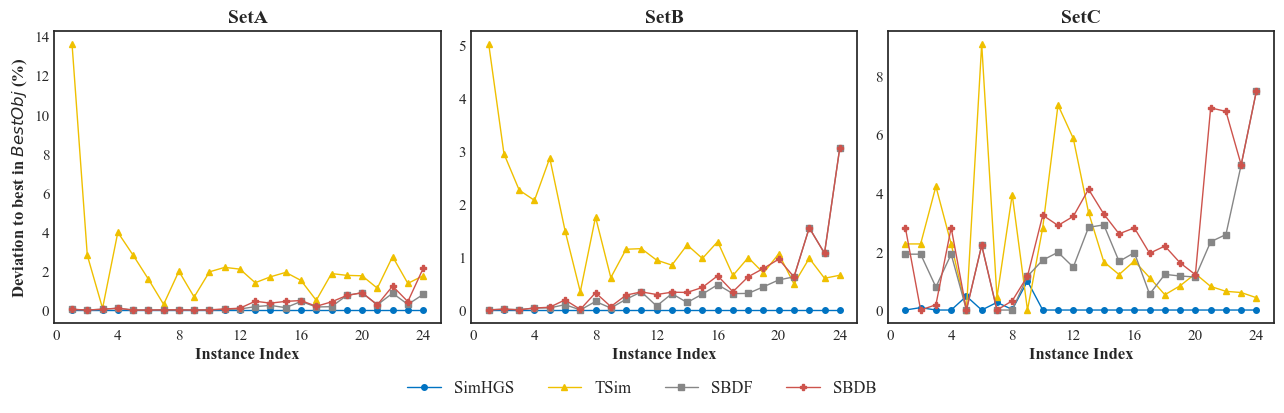

正在保存: Comparison_AvgObj_MPLStyle.pdf


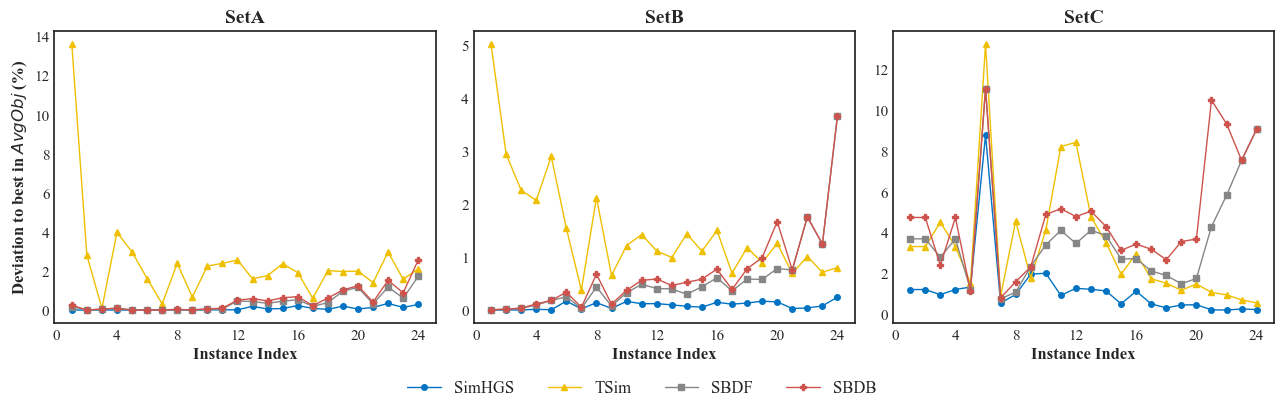

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# 设置学术字体 (Times New Roman)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
# ================= 配置区域 =================
palette = {
    'SimHGS': '#0073C2FF',
    'TSim':   '#EFC000FF',
    'SBDF':   '#868686FF',
    'SBDB':   '#CD534CFF'
}

markers = {
    'SimHGS': 'o',
    'TSim':   '^',
    'SBDF':   's',
    'SBDB':   'P'
}

# ================= 数据处理 =================
try:
    best_df = pd.read_csv('GapBstRes3.csv')
    avg_df  = pd.read_csv('GapAvgRes3.csv')
except FileNotFoundError:
    print("未找到文件，生成模拟数据演示...")
    data = []
    for s in ['SetA', 'SetB', 'SetC']:
        for i in range(1, 8):
            for alg in ['SimHGS', 'TSim', 'SBDF', 'SBDB']:
                data.append([s, f'I{i}', alg, i*1.2, i*1.0])
    mock = pd.DataFrame(data, columns=['Set', 'Instances', 'Algorithm', 'Best', 'Average'])
    best_df = mock[['Set', 'Instances', 'Algorithm', 'Best']].copy()
    avg_df  = mock[['Set', 'Instances', 'Algorithm', 'Average']].copy()

# 如果是宽表(Set, Instances, SimHGS, TSim, ...)，就 melt；如果已是长表(Set, Instances, Algorithm, value)，直接用
def ensure_long_format(df_in, value_name):
    if 'Algorithm' in df_in.columns and value_name in df_in.columns:
        return df_in[['Set', 'Instances', 'Algorithm', value_name]].copy()
    else:
        # 宽表情形
        return df_in.melt(id_vars=['Set', 'Instances'], var_name='Algorithm', value_name=value_name)

best_df = ensure_long_format(best_df, 'Best')
avg_df  = ensure_long_format(avg_df,  'Average')

df = pd.merge(best_df, avg_df, on=['Set', 'Instances', 'Algorithm'], how='inner')

# 生成 Instance Index (每个 Set 内按 Instances 出现顺序编号 1..n)
df['Instance Index'] = 0
for set_name in df['Set'].unique():
    unique_instances = df[df['Set'] == set_name]['Instances'].drop_duplicates().tolist()
    inst_map = {name: i + 1 for i, name in enumerate(unique_instances)}
    mask = df['Set'] == set_name
    df.loc[mask, 'Instance Index'] = df.loc[mask, 'Instances'].map(inst_map)

# ================= 绘图函数（按第一段风格） =================
def plot_metric_row(data, y_col, y_label, file_name):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    set_names = ['SetA', 'SetB', 'SetC']

    alg_order = [a for a in palette.keys() if a in data['Algorithm'].unique()]

    for i, set_name in enumerate(set_names):
        ax = axes[i]
        subset = data[data['Set'] == set_name].copy()

        if subset.empty:
            ax.set_title(f"{set_name} (No Data)", fontsize=14)
            ax.tick_params(axis='both', which='both', length=0)
            continue

        overall_avg = float(subset[y_col].mean())

        # 逐算法画线（matplotlib 原生）
        for alg in alg_order:
            sub_alg = subset[subset['Algorithm'] == alg].copy()
            if sub_alg.empty:
                continue

            sub_alg.sort_values('Instance Index', inplace=True)
            x = sub_alg['Instance Index'].to_numpy()
            y = sub_alg[y_col].to_numpy()

            ax.plot(
                x, y,
                color=palette[alg],
                marker=markers[alg],
                markersize=4,
                linewidth=1,
                label=alg
            )
        # 通用设置（对齐第一段）
        ax.set_title(f"{set_name}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Instance Index", fontsize=12, fontweight='bold')
        if i == 0:
            ax.set_ylabel(y_label, fontsize=12, fontweight='bold')

        #ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
        ax.tick_params(axis='both', which='both', length=0) 
        # 不画网格：默认即可（或 ax.grid(False)）

    # 底部共享 legend
    handles, labels = axes[0].get_legend_handles_labels()
    # 去重，防止重复
    seen = set()
    uniq_h, uniq_l = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            uniq_h.append(h)
            uniq_l.append(l)
            seen.add(l)

    if uniq_h:
        fig.legend(
            uniq_h, uniq_l,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.05),
            ncol=4,
            frameon=False,
            fontsize=12
        )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.17)
    print(f"正在保存: {file_name}")
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

# ================= 执行绘图 =================
plot_metric_row(df, 'Best',    r'Deviation to best in $\mathit{BestObj}$ (%)', 'Comparison_BestObj_MPLStyle.pdf')
plot_metric_row(df, 'Average', r'Deviation to best in $\mathit{AvgObj}$ (%)',  'Comparison_AvgObj_MPLStyle.pdf')


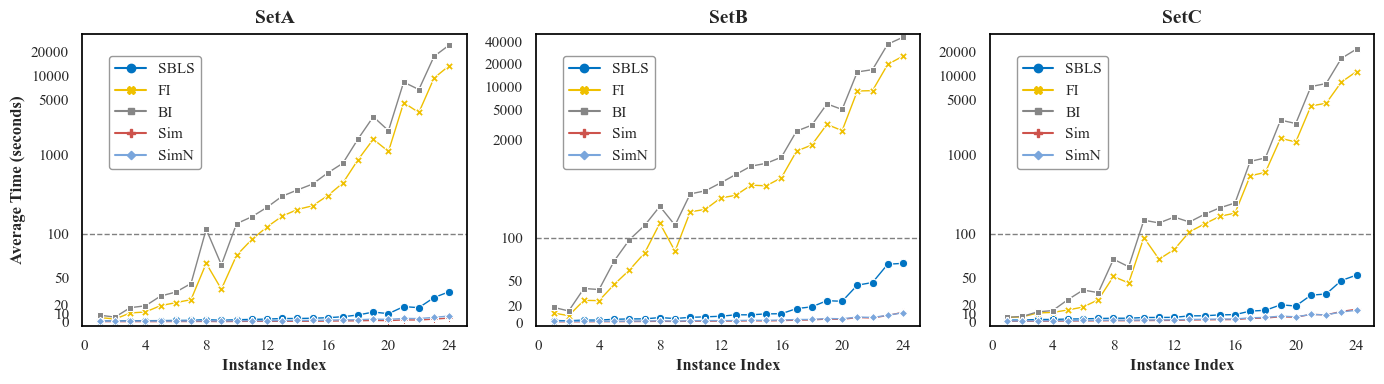

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator


plt.style.use('default')  # 重置风格：放最前面

mpl.rcParams.update({
    # Times New Roman（若系统没有，会自动用后面的候选）
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral", "DejaVu Serif"],
    "font.size": 12,

    # PDF/PS 导出时嵌入 TrueType 字体，尽量保证显示为 Times
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # 你原来的样式设置
    "axes.grid": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "axes.linewidth": 0.8,
})

# seaborn 不要再覆盖 matplotlib 字体
sns.set_theme(style="white", rc={
    "axes.grid": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral", "DejaVu Serif"],
})

# =========================================================
# 1) 配色盘（JCO）
# =========================================================
jco_colors = ['#0073C2', '#EFC000', '#868686', '#CD534C', '#7AA6DC',
              '#003C67', '#8F7700', '#3B3B3B', '#A73030', '#4A6990']

# =========================================================
# 2) 数据读取与预处理：宽表 -> 长表，并生成 Instance_Index
# =========================================================
def load_and_prep_data(filename: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        print(f"Warning: {filename} not found. Generating dummy data.")
        df = pd.DataFrame({
            'Instances': [f'Inst_{i}' for i in range(1, 21)],
            'Alg_A': np.random.uniform(0, 150, 20),
            'Alg_B': np.random.uniform(50, 5000, 20),
            'Alg_C': np.random.uniform(10, 200, 20)
        })

    # 宽表转长表
    df_long = df.melt(id_vars="Instances", var_name="Algorithm", value_name="value")

    # 按出现顺序映射为 1..n 的索引
    unique_instances = df_long['Instances'].unique()
    inst_map = {name: i + 1 for i, name in enumerate(unique_instances)}
    df_long['Instance_Index'] = df_long['Instances'].map(inst_map)

    return df_long

# =========================================================
# 3) 绘图参数
# =========================================================
files = ["MultitimeSetAX.csv", "MultitimeSetBX.csv", "MultitimeSetCX.csv"]
titles = ["SetA", "SetB", "SetC"]

y_max_limits = [30000, 45000, 30000]
y_breaks_list = [
    [0, 10, 20, 50, 100, 1000, 5000, 10000, 20000],          # Set A
    [0, 20, 50, 100, 2000, 5000, 10000, 20000, 40000],       # Set B
    [0, 10, 20, 50, 100, 1000, 5000, 10000, 20000]           # Set C
]

# =========================================================
# 4) 创建画布：1行3列子图
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
axes_flat = axes.flatten()

for i, filename in enumerate(files):
    ax = axes_flat[i]
    data = load_and_prep_data(filename)

    sns.lineplot(
        data=data, x='Instance_Index', y='value',
        hue='Algorithm', style='Algorithm',
        markers=True, dashes=False,
        palette=jco_colors[:data['Algorithm'].nunique()],
        ax=ax, linewidth=1, markersize=6
    )

    # y=100 虚线
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=1)

    # 标题
    ax.set_title(titles[i], fontsize=14, fontweight="bold", pad=8)

    # 轴标签
    ax.set_xlabel("Instance Index", fontsize=12, fontweight="bold")
    if i == 0:
        ax.set_ylabel("Average Time (seconds)", fontsize=12, fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.tick_params(axis='x', labelrotation=0)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))

    # Y轴：symlog 模拟压缩（0-100近似线性，>100对数压缩）
    ax.set_yscale('symlog', linthresh=100)

    # 自定义 Y 轴刻度
    ax.set_yticks(y_breaks_list[i])
    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())

    # Y轴范围
    ax.set_ylim(-5, y_max_limits[i] * 1.1)

    # 图例：去掉 seaborn 自动 title（Algorithm）
    leg = ax.get_legend()
    if leg is not None:
        leg.set_title(None)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles, labels=labels,
        loc='upper left',
        bbox_to_anchor=(0.05, 0.95),
        frameon=True, edgecolor='grey', facecolor='white', framealpha=0.8
    )

    # 边框颜色
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

plt.tight_layout()
plt.savefig("Combined_Plots.pdf", format='pdf', dpi=300)
plt.savefig("Combined_Plots.png", format='png', dpi=300)
plt.show()


